In [1]:
from pathlib import Path

from prismatic.vla.datasets import RLDSDataset, RLDSBatchTransform
from prismatic.util.data_utils import PaddedCollatorForActionPrediction
from prismatic.vla.action_tokenizer import ActionTokenizer
from transformers import AutoConfig, AutoImageProcessor, AutoModelForVision2Seq, AutoProcessor
from prismatic.extern.hf.configuration_prismatic import OpenVLAConfig
from prismatic.extern.hf.processing_prismatic import PrismaticImageProcessor, PrismaticProcessor

from prismatic.models.backbones.llm.prompting import PurePromptBuilder

from torch.utils.data import DataLoader
AutoProcessor.register(OpenVLAConfig, PrismaticProcessor)
processor = AutoProcessor.from_pretrained('/home/ruihengwang/vla/VLA-Adapter/pretrained_models/configs', trust_remote_code=True)
action_tokenizer = ActionTokenizer(processor.tokenizer)

batch_transform = RLDSBatchTransform(
        action_tokenizer,
        processor.tokenizer,
        image_transform=processor.image_processor.apply_transform,
        prompt_builder_fn=PurePromptBuilder,
        use_wrist_image=True,
        use_proprio=True,
        use_minivlm=True
        )

train_dataset = RLDSDataset(
        Path('/home/ruihengwang/tensorflow_datasets'),
        'beat_block_hammer_rt',
        batch_transform,
        resize_resolution=tuple([224, 224]),
        shuffle_buffer_size=100000,
        image_aug=True,
    )

collator = PaddedCollatorForActionPrediction(
        processor.tokenizer.model_max_length, processor.tokenizer.pad_token_id, padding_side="right"
    )
dataloader = DataLoader(
    train_dataset,
    batch_size=8,
    sampler=None,
    collate_fn=collator,
    num_workers=0,  # Important: Set to 0 if using RLDS, which uses its own parallelism
)

Using LIBERO constants:
  NUM_ACTIONS_CHUNK = 8
  ACTION_DIM = 7
  PROPRIO_DIM = 8
  ACTION_PROPRIO_NORMALIZATION_TYPE = bounds_q99
If needed, manually set the correct constants in `prismatic/vla/constants.py`!


2025-12-09 10:41:28.025190: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-09 10:41:28.067719: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-12-09 10:41:28.067749: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-12-09 10:41:28.069012: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-09 10:41:28.076370: I tensorflow/core/platform/cpu_feature_guar

12/09 [10:41:42] INFO     | >> Load dataset info from                                           ]8;id=693099;file:///home/ruihengwang/miniconda3/envs/vla-adapter/lib/python3.10/site-packages/tensorflow_datasets/core/dataset_info.py\dataset_info.py]8;;\:]8;id=444601;file:///home/ruihengwang/miniconda3/envs/vla-adapter/lib/python3.10/site-packages/tensorflow_datasets/core/dataset_info.py#599\599]8;;\
                          /home/ruihengwang/tensorflow_datasets/beat_block_hammer_rt/1.0.0                         

12/09 [10:41:43] INFO     | >> Constructing tf.data.Dataset beat_block_hammer_rt for split     ]8;id=9965;file:///home/ruihengwang/miniconda3/envs/vla-adapter/lib/python3.10/site-packages/tensorflow_datasets/core/logging/logging_logger.py\logging_logger.py]8;;\:]8;id=135159;file:///home/ruihengwang/miniconda3/envs/vla-adapter/lib/python3.10/site-packages/tensorflow_datasets/core/logging/logging_logger.py#49\49]8;;\
                          all, from                                                                                
                          /home/ruihengwang/tensorflow_datasets/beat_block_hammer_rt/1.0.0                         

2025-12-09 10:41:43.154194: I tensorflow/core/grappler/optimizers/data/replicate_on_split.cc:32] Running replicate on split optimization


...

                 INFO     | >> [*] Constructing datasets...                                          ]8;id=218429;file:///home/ruihengwang/vla/VLA-Adapter/prismatic/vla/datasets/rlds/dataset.py\dataset.py]8;;\:]8;id=279004;file:///home/ruihengwang/vla/VLA-Adapter/prismatic/vla/datasets/rlds/dataset.py#532\532]8;;\

                 INFO     | >> Load dataset info from                                           ]8;id=976945;file:///home/ruihengwang/miniconda3/envs/vla-adapter/lib/python3.10/site-packages/tensorflow_datasets/core/dataset_info.py\dataset_info.py]8;;\:]8;id=352792;file:///home/ruihengwang/miniconda3/envs/vla-adapter/lib/python3.10/site-packages/tensorflow_datasets/core/dataset_info.py#599\599]8;;\
                          /home/ruihengwang/tensorflow_datasets/beat_block_hammer_rt/1.0.0                         

                 INFO     | >> Constructing tf.data.Dataset beat_block_hammer_rt for split     ]8;id=510489;file:///home/ruihengwang/miniconda3/envs/vla-adapter/lib/python3.10/site-packages/tensorflow_datasets/core/logging/logging_logger.py\logging_logger.py]8;;\:]8;id=199432;file:///home/ruihengwang/miniconda3/envs/vla-adapter/lib/python3.10/site-packages/tensorflow_datasets/core/logging/logging_logger.py#49\49]8;;\
                          train, from                                                                              
                          /home/ruihengwang/tensorflow_datasets/beat_block_hammer_rt/1.0.0                         

2025-12-09 10:41:46.737495: I tensorflow/core/grappler/optimizers/data/replicate_on_split.cc:32] Running replicate on split optimization


12/09 [10:41:47] INFO     | >> [*] Applying frame transforms on dataset...                           ]8;id=821312;file:///home/ruihengwang/vla/VLA-Adapter/prismatic/vla/datasets/rlds/dataset.py\dataset.py]8;;\:]8;id=887782;file:///home/ruihengwang/vla/VLA-Adapter/prismatic/vla/datasets/rlds/dataset.py#572\572]8;;\

In [2]:
item = next(iter(dataloader))
item.keys()

W0000 00:00:1765248121.865261  985658 op_level_cost_estimator.cc:699] Error in PredictCost() for the op: op: "CropAndResize" attr { key: "T" value { type: DT_FLOAT } } attr { key: "extrapolation_value" value { f: 0 } } attr { key: "method" value { s: "bilinear" } } inputs { dtype: DT_FLOAT shape { dim { size: 1 } dim { size: 224 } dim { size: 224 } dim { size: -14 } } } inputs { dtype: DT_FLOAT shape { dim { size: -2 } dim { size: 4 } } } inputs { dtype: DT_INT32 shape { dim { size: -2 } } } inputs { dtype: DT_INT32 shape { dim { size: 2 } } } device { type: "CPU" vendor: "GenuineIntel" model: "111" frequency: 2400 num_cores: 192 environment { key: "cpu_instruction_set" value: "AVX SSE, SSE2, SSE3, SSSE3, SSE4.1, SSE4.2" } environment { key: "eigen" value: "3.4.90" } l1_cache_size: 49152 l2_cache_size: 2097152 l3_cache_size: 110100480 memory_size: 268435456 } outputs { dtype: DT_FLOAT shape { dim { size: -2 } dim { size: -20 } dim { size: -21 } dim { size: -14 } } }
W0000 00:00:1765248

dict_keys(['pixel_values', 'proprio', 'input_ids', 'attention_mask', 'labels', 'actions', 'dataset_names'])

In [3]:
item["pixel_values"].shape, item["proprio"].shape, item["input_ids"].shape, item["attention_mask"].shape, item["actions"].shape

(torch.Size([8, 18, 224, 224]),
 torch.Size([8, 14]),
 torch.Size([8, 117]),
 torch.Size([8, 117]),
 torch.Size([8, 8, 14]))

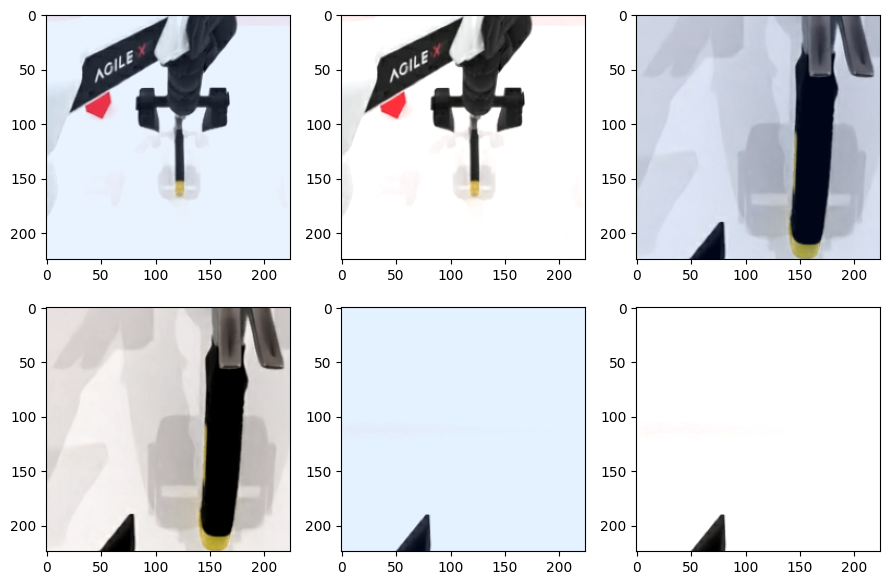

In [4]:
import matplotlib.pyplot as plt

# tensor 已经在 cpu 上，形状 [B,18,224,224]
imgs = item['pixel_values'][0]          # 拿第一张样本 [18,224,224]
# 按通道拆成 6 张 3-channel 图
pics = [imgs[i:i+3] for i in range(0, 18, 3)]   # 6 个 [3,224,224]

# 归一化到 0-1（逐张 min/max）
pics = [(p - p.min()) / (p.max() - p.min()) for p in pics]

# 画图
fig, axs = plt.subplots(2, 3, figsize=(9, 6))
for idx, ax in enumerate(axs.flat):
    ax.imshow(pics[idx].permute(1, 2, 0).detach().cpu().numpy())
    # ax.axis('off')
plt.tight_layout()
plt.show()